In [35]:
import pandas as pd
import numpy as np

df = pd.read_csv("../part1/cleaned_data.csv")

print("Shape:", df.shape)
display(df.head())
print("\nData Types:")
print(df.dtypes)

Shape: (1338, 12)


,age,sex,bmi,children,smoker,region,charges,blood_pressure,exercise_frequency,pre_existing_condition,occupation_risk,annual_income
0,19,female,27.900,0,yes,southwest,16884.92400,139.0,Never,True,high,104158.67
1,18,male,33.770,1,no,southeast,1725.55230,129.9,Weekly,True,moderate,43530.88
2,28,male,33.000,3,no,southeast,4449.46200,111.1,Rarely,False,high,113004.75
3,33,male,22.705,0,no,northwest,21984.47061,126.9,Rarely,False,high,185041.26
4,32,male,28.880,0,no,northwest,3866.85520,134.7,Rarely,True,low,46747.97



Data Types:
age                         int64
sex                        object
bmi                       float64
children                    int64
smoker                     object
region                     object
charges                   float64
blood_pressure            float64
exercise_frequency         object
pre_existing_condition       bool
occupation_risk            object
annual_income             float64
dtype: object


In [36]:
y_reg = df["charges"]
y_clf = (df["charges"] > df["charges"].median()).astype(int)


In [37]:
x = df.drop(columns=["charges"])
print("Feature matrix shape:", x.shape)
print("Regression target shape:", y_reg.shape)
print("Classification target shape:", y_clf.shape)

print("\nFeature columns:")
print(x.columns.tolist())

print("\nClassification label distribution:")
print(y_clf.value_counts())

print("\nMedian of charges:", y_reg.median())

Feature matrix shape: (1338, 11)
Regression target shape: (1338,)
Classification target shape: (1338,)

Feature columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'blood_pressure', 'exercise_frequency', 'pre_existing_condition', 'occupation_risk', 'annual_income']

Classification label distribution:
1    669
0    669
Name: charges, dtype: int64

Median of charges: 9382.033


In [38]:
exercise_mapping = {
    "Never": 0,
    "Rarely": 1,
    "Weekly": 2,
    "Daily": 3
}

occupation_mapping = {
    "low": 0,
    "moderate": 1,
    "high": 2
}

x["exercise_frequency"] = x["exercise_frequency"].map(exercise_mapping)
x["occupation_risk"] = x["occupation_risk"].map(occupation_mapping)

In [39]:
x = pd.get_dummies(
    x,
    columns=["sex", "smoker", "region"],
    drop_first=True
)   

In [40]:
print("Encoded Feature Matrix Shape:", x.shape)

print("\nEncoded Columns:")
print(x.columns.tolist())

print("\nData Types:")
print(x.dtypes)

Encoded Feature Matrix Shape: (1338, 13)

Encoded Columns:
['age', 'bmi', 'children', 'blood_pressure', 'exercise_frequency', 'pre_existing_condition', 'occupation_risk', 'annual_income', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Data Types:
age                         int64
bmi                       float64
children                    int64
blood_pressure            float64
exercise_frequency          int64
pre_existing_condition       bool
occupation_risk             int64
annual_income             float64
sex_male                    uint8
smoker_yes                  uint8
region_northwest            uint8
region_southeast            uint8
region_southwest            uint8
dtype: object


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [42]:
X_train_reg, X_test_reg, y_reg_train, y_reg_test = train_test_split(
    x,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [43]:
X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(
    x,
    y_clf,
    test_size=0.2,
    random_state=42
)

In [44]:
print(x.isnull().sum())

age                       0
bmi                       0
children                  0
blood_pressure            0
exercise_frequency        0
pre_existing_condition    0
occupation_risk           0
annual_income             0
sex_male                  0
smoker_yes                0
region_northwest          0
region_southeast          0
region_southwest          0
dtype: int64


In [45]:
print(x.dtypes)

age                         int64
bmi                       float64
children                    int64
blood_pressure            float64
exercise_frequency          int64
pre_existing_condition       bool
occupation_risk             int64
annual_income             float64
sex_male                    uint8
smoker_yes                  uint8
region_northwest            uint8
region_southeast            uint8
region_southwest            uint8
dtype: object


In [46]:
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [47]:
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [48]:
print("Regression")
print("Training Features:", X_train_reg_scaled.shape)
print("Testing Features:", X_test_reg_scaled.shape)
print("Training Labels:", y_reg_train.shape)
print("Testing Labels:", y_reg_test.shape)

print("\nClassification")
print("Training Features:", X_train_clf_scaled.shape)
print("Testing Features:", X_test_clf_scaled.shape)
print("Training Labels:", y_clf_train.shape)
print("Testing Labels:", y_clf_test.shape)

Regression
Training Features: (1070, 13)
Testing Features: (268, 13)
Training Labels: (1070,)
Testing Labels: (268,)

Classification
Training Features: (1070, 13)
Testing Features: (268, 13)
Training Labels: (1070,)
Testing Labels: (268,)


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_reg_scaled, y_reg_train)
y_pred_reg = linear_model.predict(X_test_reg_scaled)
mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("Linear regression performance")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

Linear regression performance
MSE: 33999438.03
R²: 0.7810


In [50]:
coefficients = pd.DataFrame({
    "feature": x.columns,
    "coefficient": linear_model.coef_
})

print("\nLinear regression coefficients")
display(coefficients)


Linear regression coefficients


,feature,coefficient
0,age,3611.372346
1,bmi,2067.220266
2,children,567.882126
3,blood_pressure,220.998871
4,exercise_frequency,259.148960
5,pre_existing_condition,-209.186289
6,occupation_risk,-218.898885
7,annual_income,703.024604
8,sex_male,-24.460808
9,smoker_yes,9608.717441


In [51]:
coefficients["absolute coefficient"] = coefficients["coefficient"].abs()

top3 = coefficients.sort_values(
    by="absolute coefficient",
    ascending=False
).head(3)

print("Top 3 features with largest absolute coefficients")
display(top3)

Top 3 features with largest absolute coefficients


,feature,coefficient,absolute coefficient
9,smoker_yes,9608.717441,9608.717441
0,age,3611.372346,3611.372346
1,bmi,2067.220266,2067.220266


In [52]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_reg_scaled,
    y_reg_train
)

ridge_pred = ridge_model.predict(
    X_test_reg_scaled
)

ridge_mse = mean_squared_error(
    y_reg_test,
    ridge_pred
)

ridge_r2 = r2_score(
    y_reg_test,
    ridge_pred
)

print("Ridge regression performance")
print(f"MSE: {ridge_mse:.2f}")
print(f"R²: {ridge_r2:.4f}")

Ridge regression performance
MSE: 34004839.29
R²: 0.7810


In [53]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

display(comparison)

,Model,MSE,R² Score
0,Linear Regression,3.399944e+07,0.781000
1,Ridge Regression,3.400484e+07,0.780965


In [54]:
print("Training Class Distribution")
print(y_clf_train.value_counts())

print("\nPercentage")
print(y_clf_train.value_counts(normalize=True)*100)

Training Class Distribution
1    547
0    523
Name: charges, dtype: int64

Percentage
1    51.121495
0    48.878505
Name: charges, dtype: float64


In [55]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_clf_scaled,y_clf_train)

LogisticRegression(max_iter=1000, random_state=42)

In [56]:
y_pred_clf = log_model.predict(X_test_clf_scaled)

In [57]:
y_prob = log_model.predict_proba(
    X_test_clf_scaled
)[:,1]

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_clf_test,y_pred_clf)
print("Confusion matrix")
print(cm)

Confusion matrix
[[134  12]
 [  9 113]]


In [59]:
from sklearn.metrics import classification_report

print(classification_report(
    y_clf_test,
    y_pred_clf
))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       146
           1       0.90      0.93      0.91       122

    accuracy                           0.92       268
   macro avg       0.92      0.92      0.92       268
weighted avg       0.92      0.92      0.92       268



In [60]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr,tpr,thresholds = roc_curve(y_clf_test, y_prob)

auc = roc_auc_score(y_clf_test,y_prob)

print("AUC :",auc)

AUC : 0.9603076577588141


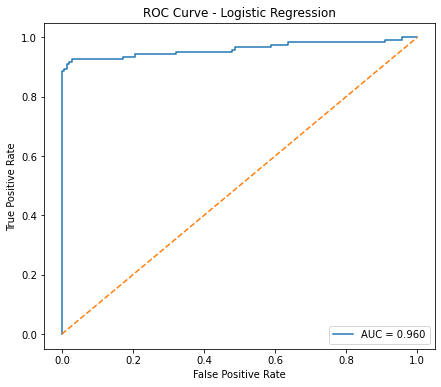

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend(loc="lower right")

plt.savefig("visual output/roc_curve.png")

plt.show()

In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_prob = log_model.predict_proba(X_test_clf_scaled)[:, 1]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    precision = precision_score(y_clf_test, y_pred_threshold)
    recall = recall_score(y_clf_test, y_pred_threshold)
    f1 = f1_score(y_clf_test, y_pred_threshold)
    
    results.append([threshold, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1 Score"]
)

display(threshold_df)

,Threshold,Precision,Recall,F1 Score
0,0.3,0.766667,0.942623,0.845588
1,0.4,0.843284,0.926230,0.882812
2,0.5,0.904000,0.926230,0.914980
3,0.6,0.949580,0.926230,0.937759
4,0.7,0.981982,0.893443,0.935622


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score

log_modelc = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

log_modelc.fit(X_train_clf_scaled,y_clf_train)

y_predc = log_modelc.predict(X_test_clf_scaled)

y_probc = log_modelc.predict_proba(X_test_clf_scaled)[:, 1]
precisionc = precision_score(y_clf_test, y_predc)
recallc = recall_score(y_clf_test, y_predc)
aucc = roc_auc_score(y_clf_test, y_probc)

print("Precision:", precisionc)
print("Recall:", recallc)
print("AUC:", aucc)


Precision: 0.8625954198473282
Recall: 0.9262295081967213
AUC: 0.9586233999550864


In [64]:
precisionc1 = precision_score(y_clf_test, y_pred_clf)
recallc1 = recall_score(y_clf_test, y_pred_clf)
aucc1 = roc_auc_score(y_clf_test, y_prob)

In [65]:
comparison = pd.DataFrame({"Model": ["Logistic Regression (C=1.0)","Logistic Regression (C=0.01)"],
    "Precision": [precisionc1, precisionc],
    "Recall": [recallc1, recallc],
    "AUC": [aucc1, aucc]
})

display(comparison)

,Model,Precision,Recall,AUC
0,Logistic Regression (C=1.0),0.904000,0.92623,0.960308
1,Logistic Regression (C=0.01),0.862595,0.92623,0.958623


In [66]:
import numpy as np
from sklearn.metrics import roc_auc_score

auc_differences = []

n_bootstrap = 500

for i in range(n_bootstrap):
    indices = np.random.choice(
        len(y_clf_test),
        size=len(y_clf_test),
        replace=True
    )

    y_boot = y_clf_test.iloc[indices]

    prob_c1 = y_prob[indices]
    prob_c001 = y_probc[indices]

    auc_c1 = roc_auc_score(y_boot, prob_c1)
    auc_c001 = roc_auc_score(y_boot, prob_c001)
    auc_differences.append(auc_c1 - auc_c001)

In [67]:
mean_difference = np.mean(auc_differences)

lower_ci = np.percentile(auc_differences, 2.5)
upper_ci = np.percentile(auc_differences, 97.5)

print("Mean AUC Difference:", round(mean_difference,6))
print("95% Confidence Interval")
print("Lower Bound:", round(lower_ci,6))
print("Upper Bound:", round(upper_ci,6))

Mean AUC Difference: 0.001656
95% Confidence Interval
Lower Bound: -0.001274
Upper Bound: 0.004655


In [68]:
if lower_ci > 0 or upper_ci < 0:
    print("\nThe 95 percent confidence interval excludes zero")
    print("The performance advantage of C=1.0 is likely consistent")
else:
    print("\nThe 95 percent confidence interval includes zero")
    print("The performance difference may not be statistically reliable")


The 95 percent confidence interval includes zero
The performance difference may not be statistically reliable
